In [7]:

import pandas as pd

In [2]:
df = pd.read_csv('datasets/data_ecommerce_customer_churn.csv')
df.head()

,Tenure,WarehouseToHome,NumberOfDeviceRegistered,PreferedOrderCat,SatisfactionScore,MaritalStatus,NumberOfAddress,Complain,DaySinceLastOrder,CashbackAmount,Churn
0,15.0,29.0,4,Laptop & Accessory,3,Single,2,0,7.0,143.32,0
1,7.0,25.0,4,Mobile,1,Married,2,0,7.0,129.29,0
2,27.0,13.0,3,Laptop & Accessory,1,Married,5,0,7.0,168.54,0
3,20.0,25.0,4,Fashion,3,Divorced,7,0,NaN,230.27,0
4,30.0,15.0,4,Others,4,Single,8,0,8.0,322.17,0


In [3]:
df.groupby('Churn')['Churn'].count() / len(df)

Churn
0    0.828977
1    0.171023
Name: Churn, dtype: float64

In [4]:
df.corr(numeric_only=True)['Churn'].sort_values(ascending=False)

Churn                       1.000000
Complain                    0.261450
NumberOfDeviceRegistered    0.108464
SatisfactionScore           0.107541
WarehouseToHome             0.073635
NumberOfAddress             0.039195
DaySinceLastOrder          -0.160446
CashbackAmount             -0.161535
Tenure                     -0.359135
Name: Churn, dtype: float64

In [5]:
df.shape

(3941, 11)

In [8]:
df.isna().sum()

Tenure                      194
WarehouseToHome             169
NumberOfDeviceRegistered      0
PreferedOrderCat              0
SatisfactionScore             0
MaritalStatus                 0
NumberOfAddress               0
Complain                      0
DaySinceLastOrder           213
CashbackAmount                0
Churn                         0
dtype: int64

In [11]:
from sklearn.model_selection import train_test_split

X = df.drop('Churn', axis=1)
y = df['Churn']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

Accuracy:  0.8531
Precision: 0.5476
Recall:    0.8661
F1-Score:  0.6709


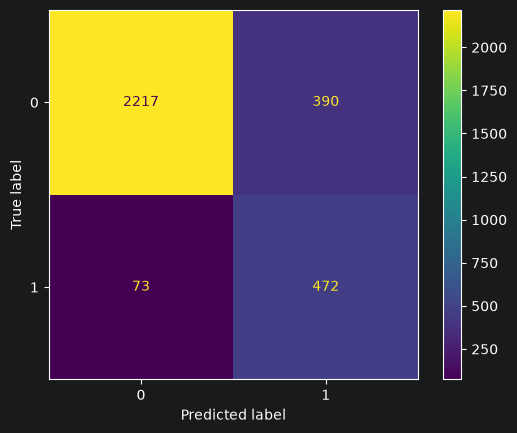

In [50]:
import xgboost as xgb

from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import f1_score, accuracy_score, recall_score, precision_score
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay


categorical_cols = X_train.select_dtypes(['category']).columns
numerical_cols = X_train.select_dtypes(['number']).columns
neg_count = (y_train == 0).sum()
pos_count = (y_train == 1).sum()
weight_ratio = neg_count / pos_count

preprocessing = ColumnTransformer([
    ('categorical', 'passthrough', categorical_cols),
    ('numerical', SimpleImputer(strategy='median'), numerical_cols),
])

pipeline = Pipeline([
    ('preprocessing', preprocessing),
    ('classifier', xgb.XGBClassifier(scale_pos_weight=weight_ratio)),
])

parameters = {
    "classifier__n_estimators": [50, 100],
    "classifier__max_depth": [3, 4, 5],
    "classifier__learning_rate": [0.03, 0.1],
    "classifier__subsample": [0.7, 0.8],
    "classifier__colsample_bytree": [0.7, 0.8],
    "classifier__min_child_weight": [1, 3, 5],
    "classifier__reg_alpha": [0, 0.1, 1],
    "classifier__reg_lambda": [1, 2],
}

grid = GridSearchCV(estimator=pipeline, cv=3, param_grid=parameters, scoring='recall', n_jobs=-1)
grid.fit(X_train, y_train)

best_model = grid.best_estimator_

y_pred = best_model.predict(X_train)

acc = accuracy_score(y_train, y_pred)
prec = precision_score(y_train, y_pred)
rec = recall_score(y_train, y_pred)
f1 = f1_score(y_train, y_pred)

print(f"Accuracy:  {acc:.4f}")
print(f"Precision: {prec:.4f}")
print(f"Recall:    {rec:.4f}")
print(f"F1-Score:  {f1:.4f}")

cm = confusion_matrix(y_train, y_pred)
ConfusionMatrixDisplay(cm).plot()

Accuracy:  0.8580
Precision: 0.5427
Recall:    0.8372
F1-Score:  0.6585


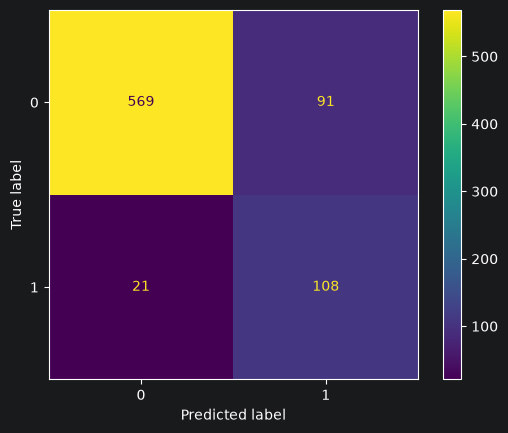

In [51]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

y_pred = best_model.predict(X_test)

acc = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred)
rec = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print(f"Accuracy:  {acc:.4f}")
print(f"Precision: {prec:.4f}")
print(f"Recall:    {rec:.4f}")
print(f"F1-Score:  {f1:.4f}")

cm = confusion_matrix(y_test, y_pred)
ConfusionMatrixDisplay(cm).plot()

In [53]:
import pickle

with open('models/model.pkl', 'wb') as file:
    pickle.dump(best_model, file)